<a href="https://colab.research.google.com/github/skoppalu/Decision-Trees/blob/main/DecisionTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor
from graphviz import Source
from sklearn.datasets import make_moons
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, train_test_split, ShuffleSplit
import pandas as pd
from scipy.stats import mode
from sklearn.metrics import accuracy_score

In [22]:
iris= load_iris(as_frame=True)
X= iris.data[['petal length (cm)', 'petal width (cm)']].values
y= iris.target

In [23]:
tree_clf= DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

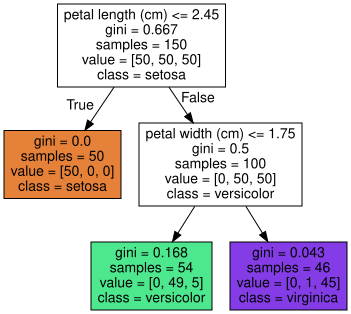

In [24]:
export_graphviz(
    tree_clf,
    out_file='tree.dot',
    feature_names=['petal length (cm)', 'petal width (cm)'],
    class_names=iris.target_names,
    filled=True
)

Source.from_file('tree.dot')

In [25]:
iris.target_names[tree_clf.predict([[3,1.3]])]

array(['versicolor'], dtype='<U10')

In [26]:
# Using the classifiers on the make moons dataset
X_moons, y_moons = make_moons(random_state=42, noise=0.2, n_samples=200)

In [27]:
# trying regularized vs unregularized
tree_clf_1= DecisionTreeClassifier(random_state=42)
tree_clf_2= DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf_1.fit(X_moons, y_moons)
tree_clf_2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [28]:
# unregularized model is probably overfitting
print(tree_clf_1.score(X_moons, y_moons))
print(tree_clf_2.score(X_moons, y_moons))

1.0
0.975


# Regression using Decision Trees

In [29]:
# taking a quadratic dataset

rng= np.random.default_rng(seed=42)

X_quad= rng.random((200,1))-0.5 # -0.5 will center it around zero

y_quad = (X_quad ** 2 + rng.standard_normal((200,1)) * 0.00025).round(2)

In [30]:
tree_reg = DecisionTreeRegressor(min_samples_leaf=10, max_depth=2,random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, min_samples_leaf=10, random_state=42)

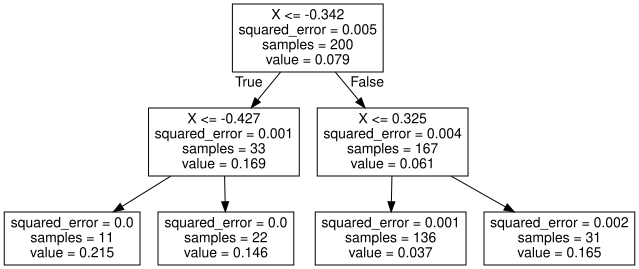

In [31]:
export_graphviz(
    tree_reg,
    out_file='tree.dot',
    feature_names=['X'],

)

Source.from_file('tree.dot')

In [32]:
preds=tree_reg.predict(X_quad).round(2)

mean_squared_error(y_quad, preds)

0.0010670000000000002

# Sensitivity to Axis Rotation

In [33]:
pca_pipeline= make_pipeline(StandardScaler(), PCA())

X_iris_rotated = pca_pipeline.fit_transform(X)

tree_clf= DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf.fit(X_iris_rotated, y)

tree_clf.score(X_iris_rotated, y)

# We see that it performs better after making sure data is not correlated and making it easy for the orthogonal decision boundaries

0.98

**Using grid search on make moons classification**

In [34]:
grid={
    'max_leaf_nodes':rng.integers(low=2,high=20, size=30)
}


X, y= make_moons(n_samples=10000, noise=0.4)


X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size=0.1)

tree_clf=DecisionTreeClassifier(random_state=42)

grid_search= GridSearchCV(tree_clf, grid, cv=3)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_leaf_nodes': array([13,  3, 14, 18, 17,  2,  6,  6, 10,  4, 17, 15, 16,  5,  2, 18,  7,
       13, 18,  2,  2,  2,  4,  2, 16, 12, 19, 16, 19,  6])})

In [35]:
best_est= grid_search.best_estimator_

best_est.score(X_test, y_test)

0.859

In [36]:
pd.DataFrame(grid_search.cv_results_).sort_values(by='rank_test_score').head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
26,0.038598,0.012650,0.004086,0.003080,19,{'max_leaf_nodes': 19},0.867333,0.852667,0.847667,0.855889,0.008346,1
28,0.032306,0.012838,0.003876,0.001679,19,{'max_leaf_nodes': 19},0.867333,0.852667,0.847667,0.855889,0.008346,1
11,0.027402,0.009292,0.002443,0.000800,15,{'max_leaf_nodes': 15},0.869000,0.854667,0.839333,0.854333,0.012114,3


**Building a Random Forest**

In [37]:
# Creating 100 subsets
splitter=ShuffleSplit(n_splits=1000, test_size=len(X_train)-100, random_state=42)

split_data=[]

for i, (train_idx, test_idx) in enumerate(splitter.split(X_train)):

  split_data.append((X_train[train_idx], y_train[train_idx]))


In [38]:
# Training 100 Decisions Trees

trees=[]
scores=[]


for X_train_data, y_train_data in split_data:
  tree_clf= DecisionTreeClassifier(random_state=42, max_leaf_nodes=14)
  tree_clf.fit(X_train_data, y_train_data)

  trees.append(tree_clf)


In [39]:
# # checking performance of a 2 randomly chosen trees

rng= np.random.default_rng(seed=42)

tree1= trees[rng.integers(0,100)]
tree2= trees[rng.integers(0,100)]

print(tree1.score(X_test, y_test))
print(tree1.score(X_test, y_test))



preds=[]

for instance in X_test:

  tree_preds=[]
  for tree in trees:

    tree_preds.append(tree.predict([instance]))


  majority_vote=mode(tree_preds)
  preds.append(majority_vote.mode[0])

accuracy_score(y_test, preds)


# we achieve 0.4% increase in prediction accuracy compared to a single decision tree trained on the entire dataset
# shows that large number of trees capture more variance and by averaging results from all trees we get better results

0.827
0.827


0.864